# Análisis de resultados del OE2: los 12 experimentos y las pruebas que explican sus resultados

Este cuaderno lee los CSV de resultados que ya están en el repositorio y **regenera las 10 figuras** de la carpeta [`figuras/`](figuras/).
No entrena ningún modelo, no usa la API de Claude y tarda menos de un minuto.

**Resultado vigente:** protocolo B (C elegido por validación cruzada interna con K=5), 7 intenciones, corpus original, texto normalizado sin `¿?`, embeddings congelados (mBERT, LaBSE, XLM-R) + Regresión Logística, 5 folds congelados.

| Figura | Pregunta que responde | Datos de origen |
|---|---|---|
| 1 | ¿Cuánto vale cada uno de los 12 experimentos? | `evaluacion/resultados/cv_interna/` |
| 2 | ¿Alguna técnica supera al baseline? | `evaluacion/resultados/cv_interna/` |
| 3 | ¿Por qué gana mBERT? | `evaluacion/diagnostico_baseline/resultados/ngramas_caracteres.csv`, `oe3.../f1_por_pooling.csv` |
| 4 | ¿Es que ya no hay nada más que aprender (techo de datos)? | `evaluacion/diagnostico_baseline/resultados/A_curva_aprendizaje.csv` |
| 5 | ¿Con pocos datos reales sí ayuda el aumento? | `evaluacion/resultados/curva_regimen/` |
| 6 | ¿Lo sintético vale tanto como lo real? | `evaluacion/diagnostico_baseline/resultados/B_utilidad_sintetico.csv` |
| 7 | ¿Está balanceado el sintético de GtR y qué parte perjudica? | `C_dosis.csv`, `C_por_categoria.csv` y la caché de GtR |
| 8 | ¿Qué clases suben o bajan con cada técnica? | predicciones de los 12 experimentos |
| 9 | ¿Por qué el F1 se estanca al agregar más sintético? ¿Es ruido? | `E_curva_por_lotes.csv`, `E_estadisticas_por_lote.csv` |
| 10 | ¿Se arregla seleccionando mejor el sintético? | `evaluacion/resultados/variantes_gtr/` |

**Cómo correrlo:** abrir el cuaderno y ejecutar todas las celdas (en VS Code o Jupyter). Las figuras se guardan en `figuras/` junto a este archivo.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shiwilu").is_dir() and (p / "oe2_aumento_de_datos").is_dir())
OE2 = RAIZ / "oe2_aumento_de_datos"
CV = OE2 / "evaluacion/resultados/cv_interna"
DIAG = OE2 / "evaluacion/diagnostico_baseline/resultados"
REG = OE2 / "evaluacion/resultados/curva_regimen"
SAL = OE2 / "analisis_resultados" / "figuras"
SAL.mkdir(exist_ok=True)

MOD = ["mbert", "labse", "xlmr"]; NOM = {"mbert": "mBERT", "labse": "LaBSE", "xlmr": "XLM-R"}
TEC = ["sin_aumento", "mixup", "retrotraduccion", "generate_then_refine"]
TNOM = {"sin_aumento": "Sin aumento", "mixup": "Mixup", "retrotraduccion": "Retrotraducción", "generate_then_refine": "Generate-then-Refine"}
COL = {"sin_aumento": "#212121", "mixup": "#1976d2", "retrotraduccion": "#f57c00", "generate_then_refine": "#2e7d32"}
CLASES = ["AFI", "DES", "EMO", "NEG", "PRG", "REQUEST", "SAL"]
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 130})


def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(SAL / nombre, bbox_inches="tight")
    plt.show()
    print("figura:", nombre)
print('raíz del repositorio:', RAIZ)

raíz del repositorio: C:\Lhia\Cursos Catolica\2026\TESIS\repo tesis\shiwilu-tesis


## Datos de los 12 experimentos

Tres archivos del protocolo B con GtR de 120 oraciones por categoría: el **resumen** (F1 macro agrupado con su IC 95% bootstrap), las **diferencias pareadas** frente a «sin aumento» y las **predicciones** de las 700 oraciones.

In [2]:
R = pd.read_csv(CV / "validacion_cruzada_resumen_sin_puntuacion_cv_interna_c120.csv")
D = pd.read_csv(CV / "comparacion_pareada_sin_puntuacion_cv_interna_c120.csv")
P = pd.read_csv(CV / "validacion_cruzada_predicciones_sin_puntuacion_cv_interna_c120.csv")
R.pivot(index='modelo', columns='tecnica', values='f1_macro_agrupado').round(3)

tecnica,generate_then_refine,mixup,retrotraduccion,sin_aumento
modelo,,,,
labse,0.593,0.587,0.581,0.587
mbert,0.652,0.629,0.631,0.665
xlmr,0.589,0.546,0.551,0.570


## Figura 1. Los 12 experimentos

**Cómo leerla:** cada punto es el F1 macro de una combinación modelo × técnica y la barra es su IC 95%. Si dos barras se solapan mucho, no se puede decir que una sea mejor.

**Qué se ve:** mBERT sin aumento (0.665) es el punto más alto de todos. En LaBSE las cuatro configuraciones quedan casi iguales. En XLM-R, GtR queda arriba pero con intervalo solapado.

**Conclusión:** el mejor resultado del OE2 es **mBERT sin aumento**; con el corpus completo, el aumento no supera al baseline. *Firmeza: fuerte.*

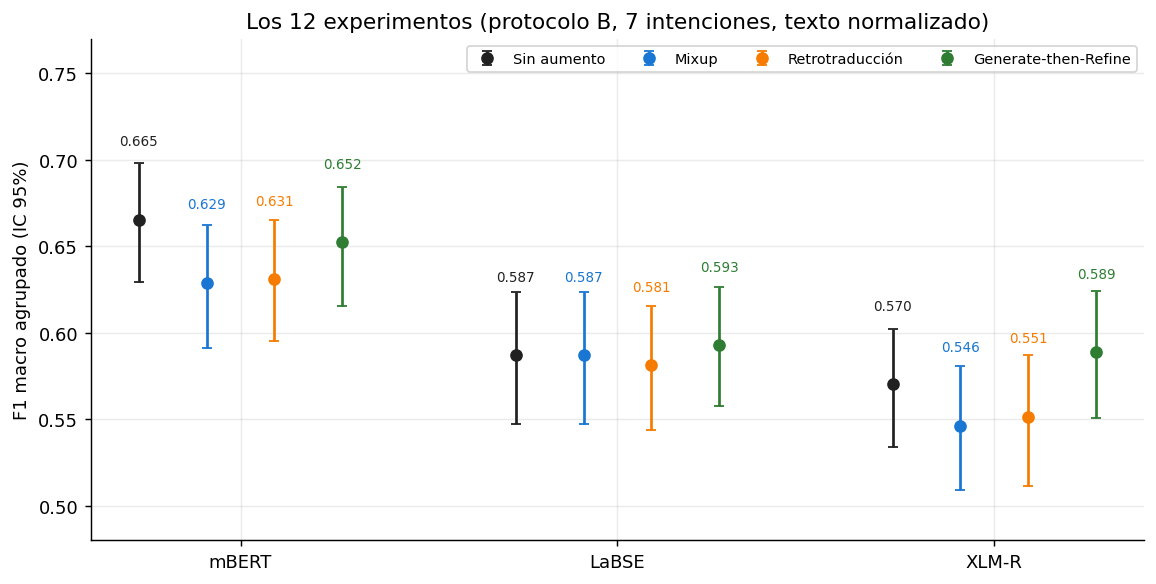

figura: fig1_f1_12_experimentos.png


In [3]:
# ---------------------------------------------------------------- 1. los 12 experimentos
fig, ax = plt.subplots(figsize=(9, 4.6))
for j, t in enumerate(TEC):
    x = np.arange(3) + (j - 1.5) * 0.18
    y = [R[(R.modelo == m) & (R.tecnica == t)].f1_macro_agrupado.iloc[0] for m in MOD]
    lo = [y[i] - R[(R.modelo == m) & (R.tecnica == t)].ic95_bajo.iloc[0] for i, m in enumerate(MOD)]
    hi = [R[(R.modelo == m) & (R.tecnica == t)].ic95_alto.iloc[0] - y[i] for i, m in enumerate(MOD)]
    ax.errorbar(x, y, yerr=[lo, hi], fmt="o", color=COL[t], capsize=3, label=TNOM[t], markersize=6)
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.043, f"{yi:.3f}", ha="center", fontsize=7.5, color=COL[t])
ax.set_xticks(range(3)); ax.set_xticklabels([NOM[m] for m in MOD]); ax.set_ylabel("F1 macro agrupado (IC 95%)")
ax.set_title("Los 12 experimentos (protocolo B, 7 intenciones, texto normalizado)"); ax.set_ylim(0.48, 0.77); ax.legend(ncol=4, fontsize=8, loc="upper right")
guardar(fig, "fig1_f1_12_experimentos.png")

## Figura 2. Diferencias pareadas frente a «sin aumento»

**Cómo leerla:** cada fila compara una técnica con el baseline del mismo modelo **sobre las mismas oraciones** (más sensible que comparar las barras de la Figura 1). El punto relleno es una diferencia distinguible de cero (el intervalo no incluye 0); el hueco no lo es. A la izquierda de la línea, la técnica empeora.

**Qué se ve:** las tres diferencias distinguibles son negativas (Mixup en mBERT y XLM-R, Retrotraducción en mBERT). GtR es la menos mala: ninguna diferencia suya es distinguible.

**Conclusión:** **ninguna técnica mejora de forma distinguible** al baseline con todos los datos. *Firmeza: fuerte.*

In [4]:
D.round(3)

,comparacion,diferencia_f1,ic95_bajo,ic95_alto,distinguible_de_cero
0,labse: mixup - sin_aumento,-0.000,-0.017,0.018,False
1,labse: retrotraduccion - sin_aumento,-0.006,-0.034,0.022,False
2,labse: generate_then_refine - sin_aumento,0.006,-0.019,0.031,False
3,mbert: mixup - sin_aumento,-0.036,-0.053,-0.020,True
4,mbert: retrotraduccion - sin_aumento,-0.034,-0.061,-0.007,True
5,mbert: generate_then_refine - sin_aumento,-0.013,-0.037,0.010,False
6,xlmr: mixup - sin_aumento,-0.024,-0.040,-0.009,True
7,xlmr: retrotraduccion - sin_aumento,-0.019,-0.045,0.007,False
8,xlmr: generate_then_refine - sin_aumento,0.018,-0.004,0.042,False
9,sin_aumento: xlmr - mbert,-0.095,-0.132,-0.058,True


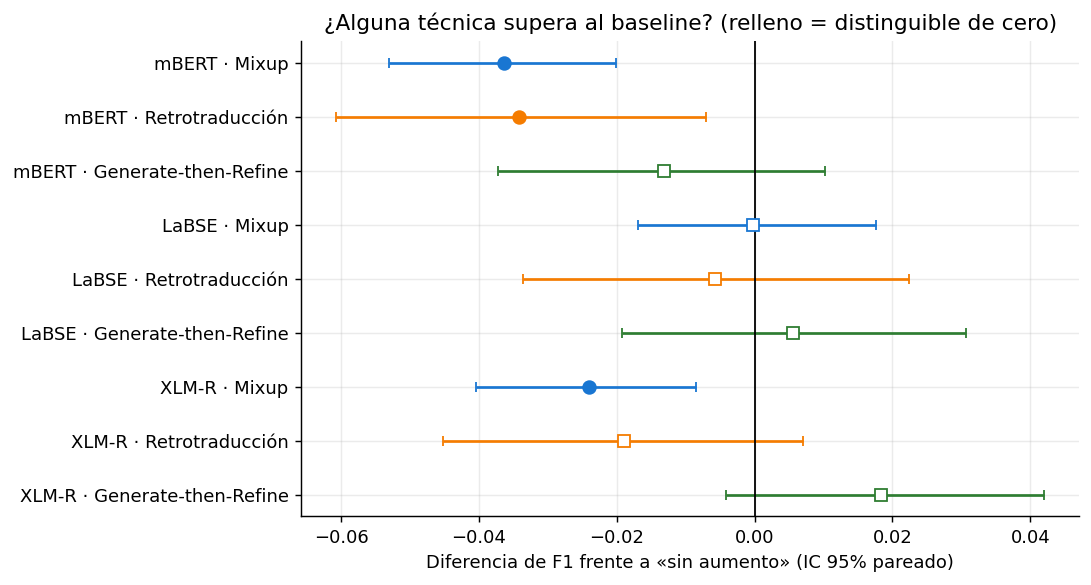

figura: fig2_diferencias_pareadas.png


In [5]:
# ---------------------------------------------------------------- 2. diferencias pareadas
fig, ax = plt.subplots(figsize=(8.5, 4.6))
filas = []
for m in MOD:
    for t in TEC[1:]:
        r = D[D.comparacion == f"{m}: {t} - sin_aumento"].iloc[0]
        filas.append((f"{NOM[m]} · {TNOM[t]}", r.diferencia_f1, r.ic95_bajo, r.ic95_alto, r.distinguible_de_cero, t))
for i, (n, d, lo, hi, sig, t) in enumerate(filas[::-1]):
    ax.errorbar(d, i, xerr=[[d - lo], [hi - d]], fmt="o" if sig else "s", color=COL[t], mfc=COL[t] if sig else "white", capsize=3, markersize=7)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(filas))); ax.set_yticklabels([f[0] for f in filas[::-1]]); ax.set_xlabel("Diferencia de F1 frente a «sin aumento» (IC 95% pareado)")
ax.set_title("¿Alguna técnica supera al baseline? (relleno = distinguible de cero)")
guardar(fig, "fig2_diferencias_pareadas.png")

## Figura 3. ¿Por qué gana mBERT?

**Panel izquierdo:** un clasificador que **solo mira n-gramas de letras** (sin ningún modelo de lenguaje) saca 0.751, mejor que los tres embeddings congelados. En este corpus la intención se reconoce sobre todo por la **forma de las palabras** (sufijos y partículas como *i'n*, *a'cha*, *-r'*, *ajá*).

**Panel derecho:** con las cuatro estrategias de pooling, mBERT gana siempre; la estrategia importa (hasta ~0.05).

**Conclusión:** la ventaja de mBERT es **coherente con** que conserva mejor la forma de las letras. *Firmeza: media (no es una prueba causal).*

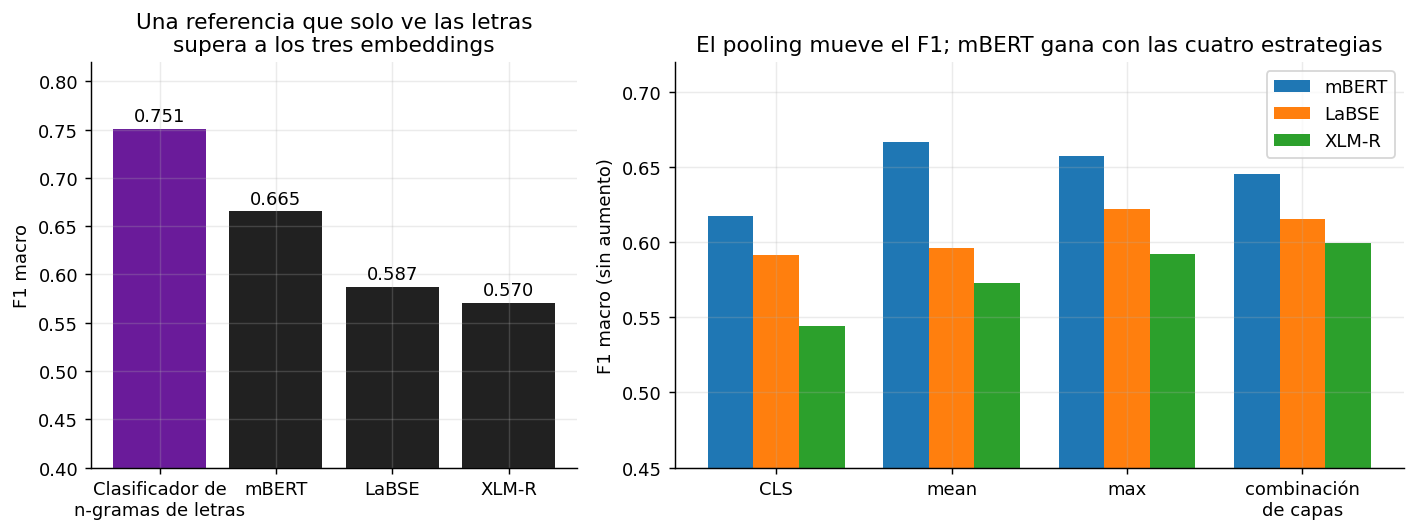

figura: fig3_por_que_gana_mbert.png


In [6]:
# ---------------------------------------------------------------- 3. por que gana mBERT: referencia de caracteres y pooling
ng = pd.read_csv(DIAG / "ngramas_caracteres.csv").iloc[0]
fp = pd.read_csv(RAIZ / "oe3_caracterizacion_embeddings/resultados/f1_por_pooling.csv")
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})
ax = ejes[0]
vals = [("Clasificador de\nn-gramas de letras", ng.f1_macro_agrupado, "#6a1b9a")] + [(NOM[m], R[(R.modelo == m) & (R.tecnica == "sin_aumento")].f1_macro_agrupado.iloc[0], "#212121") for m in MOD]
ax.bar([v[0] for v in vals], [v[1] for v in vals], color=[v[2] for v in vals])
for i, v in enumerate(vals):
    ax.text(i, v[1] + 0.008, f"{v[1]:.3f}", ha="center")
ax.set_ylim(0.4, 0.82); ax.set_ylabel("F1 macro"); ax.set_title("Una referencia que solo ve las letras\nsupera a los tres embeddings")
ax = ejes[1]
est = ["cls", "mean_pooling", "max_pooling", "combinacion_capas"]; enom = ["CLS", "mean", "max", "combinación\nde capas"]
for j, m in enumerate(MOD):
    y = [fp[(fp.modelo == m) & (fp.estrategia == e) & (fp.corpus == "sin aumento")].f1_macro.iloc[0] for e in est]
    ax.bar(np.arange(4) + (j - 1) * 0.26, y, 0.26, label=NOM[m])
ax.set_xticks(range(4)); ax.set_xticklabels(enom); ax.set_ylim(0.45, 0.72); ax.set_ylabel("F1 macro (sin aumento)"); ax.legend()
ax.set_title("El pooling mueve el F1; mBERT gana con las cuatro estrategias")
guardar(fig, "fig3_por_que_gana_mbert.png")

### Figura 3b. Versión solo del OE2 de la Figura 3

La Figura 3 combina el clasificador de n-gramas (OE2) con el F1 por estrategia de pooling (OE3). Para el capítulo del OE2 se usa solo la comparación del clasificador que cuenta fragmentos de letras frente a los tres baselines con embeddings.

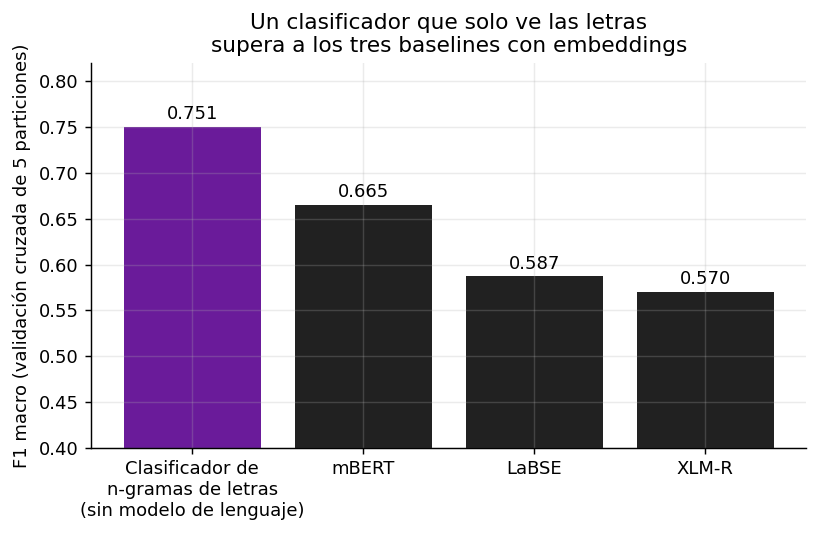

figura: fig3b_ngramas_vs_baselines.png


In [7]:
vals = [("Clasificador de\nn-gramas de letras\n(sin modelo de lenguaje)", ng.f1_macro_agrupado, "#6a1b9a")] + [(NOM[m], R[(R.modelo == m) & (R.tecnica == "sin_aumento")].f1_macro_agrupado.iloc[0], "#212121") for m in MOD]
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.bar([v[0] for v in vals], [v[1] for v in vals], color=[v[2] for v in vals])
for i, v in enumerate(vals):
    ax.text(i, v[1] + 0.008, f"{v[1]:.3f}", ha="center")
ax.set_ylim(0.4, 0.82); ax.set_ylabel("F1 macro (validación cruzada de 5 particiones)")
ax.set_title("Un clasificador que solo ve las letras\nsupera a los tres baselines con embeddings")
guardar(fig, "fig3b_ngramas_vs_baselines.png")

## Figura 4. ¿Es un techo de datos? Curva de aprendizaje con datos reales

**Cómo leerla:** se entrena con 25%, 50%, 75% y 100% de las ~560 oraciones reales de entrenamiento (sin aumento, C fijo). El número junto al último punto es la ganancia del último tramo.

**Qué se ve:** mBERT sigue subiendo (+0.037 en el último tramo); LaBSE y XLM-R se aplanan (+0.010 y +0.016).

**Conclusión:** que el aumento no ayude a mBERT **no** se debe a que ya no pueda mejorar: más datos *reales* lo ayudarían. *Firmeza: media.*

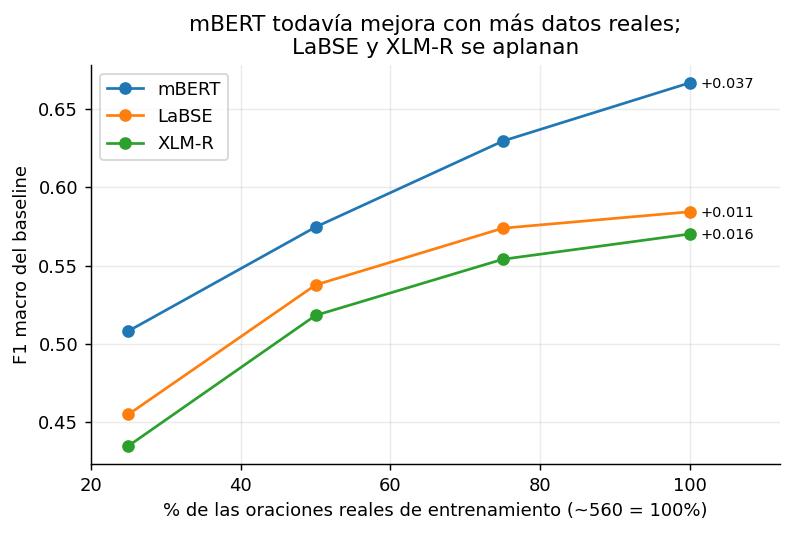

figura: fig4_curva_aprendizaje_real.png


In [8]:
# ---------------------------------------------------------------- 4. curva de aprendizaje con datos reales
A = pd.read_csv(DIAG / "A_curva_aprendizaje.csv")
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for m in MOD:
    a = A[A.modelo == m]
    ax.plot(a.fraccion_de_reales * 100, a.f1_macro, marker="o", label=NOM[m])
    ax.annotate(f"+{a.f1_macro.iloc[-1] - a.f1_macro.iloc[-2]:.3f}", (100, a.f1_macro.iloc[-1]), textcoords="offset points", xytext=(6, -3), fontsize=8)
ax.set_xlabel("% de las oraciones reales de entrenamiento (~560 = 100%)"); ax.set_ylabel("F1 macro del baseline"); ax.set_xlim(20, 112)
ax.set_title("mBERT todavía mejora con más datos reales;\nLaBSE y XLM-R se aplanan"); ax.legend()
guardar(fig, "fig4_curva_aprendizaje_real.png")

## Figura 5. Curva por régimen de datos reales (10, 25, 50 y 80 por clase)

**Cómo leerla:** fila superior, F1 macro de cada técnica según cuántos ejemplos reales por clase hay. Fila inferior, la diferencia frente a «sin aumento» con su IC 95% pareado; el asterisco marca las distinguibles de cero. En cada régimen, GtR se generó de nuevo usando **solo** las oraciones de ese régimen.

**Qué se ve:** GtR mejora a los tres modelos con 10 y 25 por clase (+0.03 a +0.05), la ventaja se reduce con 50 y desaparece con 80. Mixup y Retrotraducción no ayudan en ningún régimen.

**Conclusión:** el aumento con GtR **sirve en recursos extremos** y deja de servir cuando hay más datos reales. *Firmeza: fuerte en dirección; una sola muestra de reales por régimen.*

In [9]:
# ---------------------------------------------------------------- 5. curva por regimen
RR = pd.read_csv(REG / "resumen_por_regimen.csv"); RD = pd.read_csv(REG / "comparacion_pareada.csv")
RR[RR.tecnica.isin(['sin_aumento','generate_then_refine'])].pivot_table(index=['modelo','tecnica'], columns='regimen', values='f1_macro').round(3)

regimen                         10     25     50     80
modelo tecnica                                         
labse  generate_then_refine  0.432  0.523  0.584  0.580
       sin_aumento           0.383  0.495  0.570  0.587
mbert  generate_then_refine  0.503  0.599  0.632  0.656
       sin_aumento           0.431  0.527  0.600  0.665
xlmr   generate_then_refine  0.423  0.519  0.544  0.589
       sin_aumento           0.372  0.464  0.531  0.570

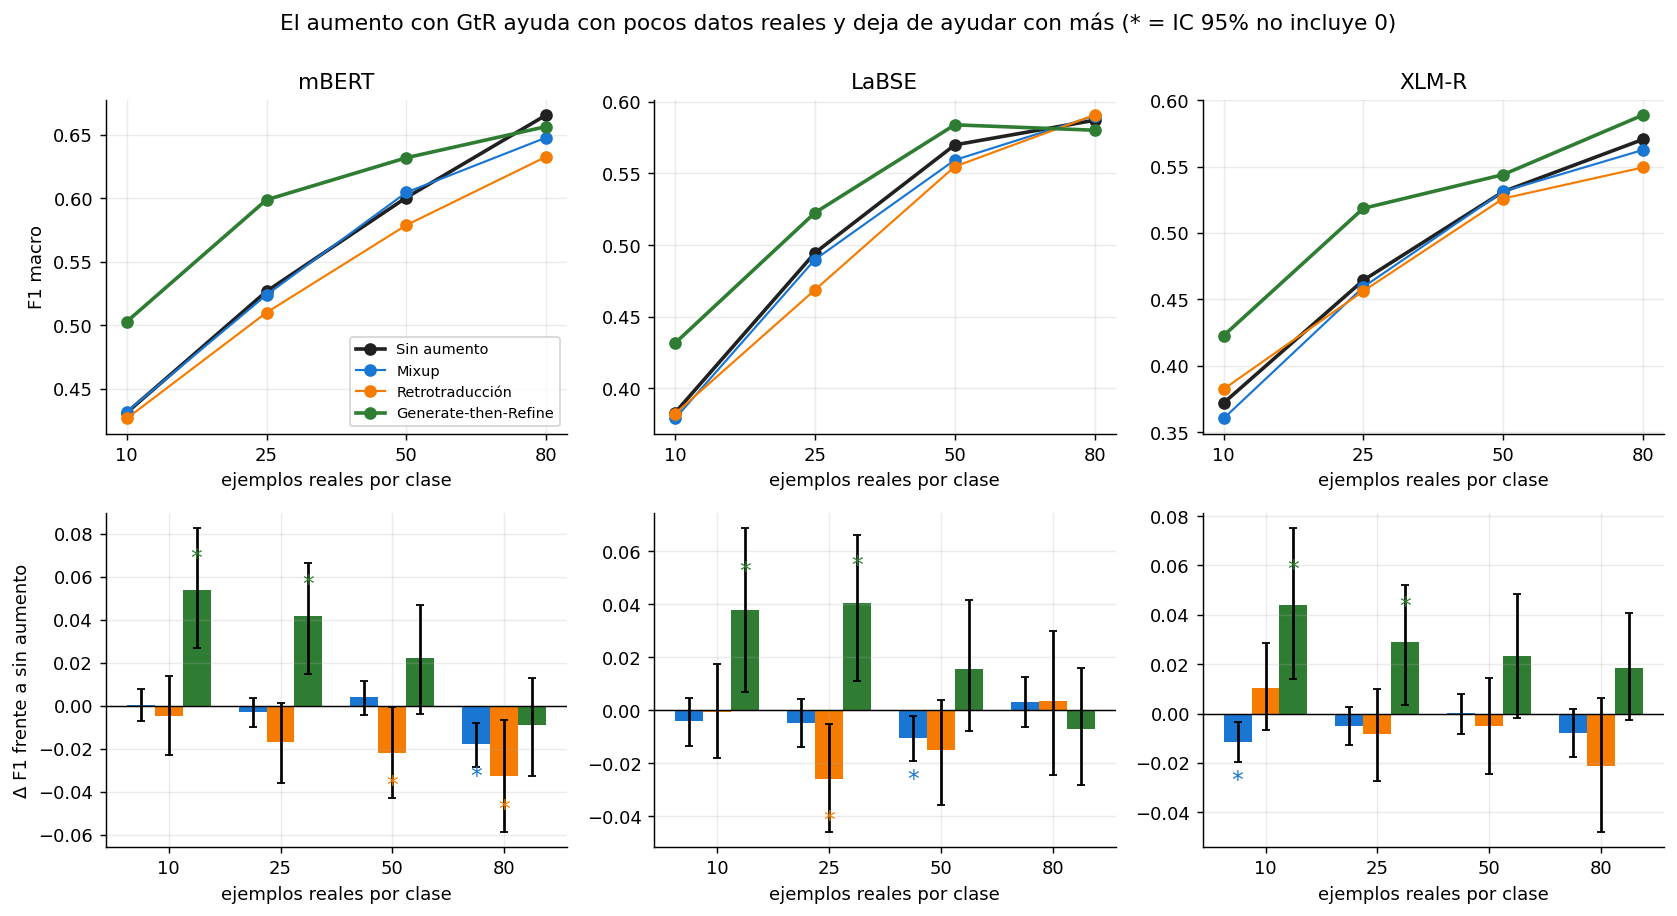

figura: fig5_curva_por_regimen.png


In [10]:
fig, ejes = plt.subplots(2, 3, figsize=(13, 7))
POS = {10: 0, 25: 1, 50: 2, 80: 3}
for j, m in enumerate(MOD):
    ax = ejes[0, j]
    for t in TEC:
        g = RR[(RR.modelo == m) & (RR.tecnica == t)].sort_values("regimen")
        ax.plot([POS[r] for r in g.regimen], g.f1_macro, marker="o", color=COL[t], label=TNOM[t], lw=2 if t in ("sin_aumento", "generate_then_refine") else 1.2)
    ax.set_title(NOM[m]); ax.set_xticks(range(4)); ax.set_xticklabels(["10", "25", "50", "80"]); ax.set_xlabel("ejemplos reales por clase")
    if j == 0:
        ax.set_ylabel("F1 macro"); ax.legend(fontsize=8)
    ax = ejes[1, j]
    for k, t in enumerate(TEC[1:]):
        g = RD[(RD.modelo == m) & (RD.tecnica == t)].sort_values("regimen")
        xs = np.arange(4) + (k - 1) * 0.25
        ax.bar(xs, g.dif_vs_sin_aumento, 0.25, color=COL[t], yerr=[g.dif_vs_sin_aumento - g.ic95_bajo, g.ic95_alto - g.dif_vs_sin_aumento], capsize=2, label=TNOM[t])
        for xi, d, s in zip(xs, g.dif_vs_sin_aumento, g.distinguible_de_cero):
            if s:
                ax.text(xi, d + (0.012 if d > 0 else -0.018), "*", ha="center", fontsize=13, color=COL[t])
    ax.axhline(0, color="k", lw=0.8); ax.set_xticks(range(4)); ax.set_xticklabels(["10", "25", "50", "80"]); ax.set_xlabel("ejemplos reales por clase")
    if j == 0:
        ax.set_ylabel("Δ F1 frente a sin aumento")
fig.suptitle("El aumento con GtR ayuda con pocos datos reales y deja de ayudar con más (* = IC 95% no incluye 0)", y=1.0)
guardar(fig, "fig5_curva_por_regimen.png")

## Figura 6. ¿Lo sintético vale tanto como lo real? (mBERT, LaBSE, XLM-R con C fijo)

**(a)** F1 entrenando **solo** con lo sintético (la línea punteada es el F1 con las reales). **(b)** Qué porcentaje de las etiquetas sintéticas coincide con la predicción de un clasificador entrenado con reales (la línea es el acierto en reales nuevas). **(c)** AUC para separar real de sintético (0.5 = indistinguibles; 1 = totalmente distintos).

**Qué se ve:** GtR se distingue de lo real (AUC ≈ 0.8) y sus etiquetas coinciden *más* que las de reales nuevas: son ejemplos típicos y fáciles. En Retrotraducción solo ~52% de las etiquetas coincide (ruido de etiqueta). Mixup es casi copia de las reales (redundante).

**Conclusión:** lo sintético aporta menos información que lo real. *Firmeza: media; efectos individuales ≤0.02.*

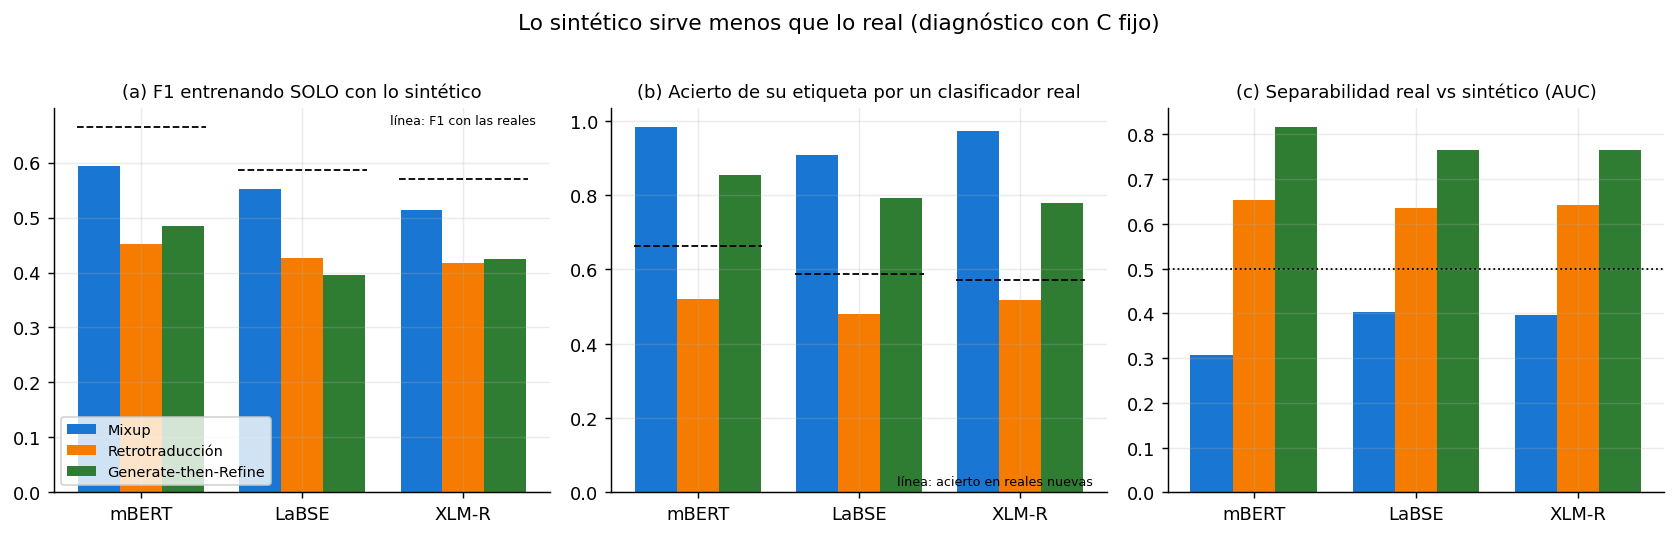

figura: fig6_utilidad_sintetico.png


In [11]:
# ---------------------------------------------------------------- 6. utilidad de lo sintetico
B = pd.read_csv(DIAG / "B_utilidad_sintetico.csv")
acc = {m: float((P[(P.modelo == m) & (P.tecnica == "sin_aumento")].real == P[(P.modelo == m) & (P.tecnica == "sin_aumento")].prediccion).mean()) for m in MOD}
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
tt = ["mixup", "retrotraduccion", "generate_then_refine"]
for ax, col, tit in zip(ejes, ["B1_f1_solo_sinteticos", "B2_concordancia_etiqueta", "B4_auc_real_vs_sintetico"],
                        ["(a) F1 entrenando SOLO con lo sintético", "(b) Acierto de su etiqueta por un clasificador real", "(c) Separabilidad real vs sintético (AUC)"]):
    for j, t in enumerate(tt):
        y = [B[(B.tecnica == t) & (B.modelo == m)][col].iloc[0] for m in MOD]
        ax.bar(np.arange(3) + (j - 1) * 0.26, y, 0.26, color=COL[t], label=TNOM[t])
    ax.set_xticks(range(3)); ax.set_xticklabels([NOM[m] for m in MOD]); ax.set_title(tit, fontsize=10)
    if col == "B1_f1_solo_sinteticos":
        for i, m in enumerate(MOD):
            ax.hlines(R[(R.modelo == m) & (R.tecnica == "sin_aumento")].f1_macro_agrupado.iloc[0], i - 0.4, i + 0.4, color="k", ls="--", lw=1)
        ax.text(2.45, 0.67, "línea: F1 con las reales", fontsize=7, ha="right")
    if col == "B2_concordancia_etiqueta":
        for i, m in enumerate(MOD):
            ax.hlines(acc[m], i - 0.4, i + 0.4, color="k", ls="--", lw=1)
        ax.text(2.45, 0.02, "línea: acierto en reales nuevas", fontsize=7, ha="right")
    if col == "B4_auc_real_vs_sintetico":
        ax.axhline(0.5, color="k", ls=":", lw=1)
ejes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Lo sintético sirve menos que lo real (diagnóstico con C fijo)", y=1.02)
guardar(fig, "fig6_utilidad_sintetico.png")

## Figura 7. Composición y dosis del sintético de GtR

**(a)** Oraciones aprobadas por clase en un fold, frente a ~80 reales: DES y SAL quedan sobrerrepresentadas y EMO y AFI, subrepresentadas (los filtros de marcador dejan pasar casi todo DES/SAL y rechazan EMO/AFI/REQUEST). **(b)** F1 según el % de sintético agregado; la estrella es el sintético **balanceado**. **(c)** Cambio del F1 de mBERT al agregar solo el sintético de cada clase.

**Conclusión:** en mBERT, más sintético no mejora (0.667 → 0.655), y el sintético de DES, PRG y SAL es el que más perjudica. Ojo: la variante 10 (abajo) muestra que quitar el de DES del conjunto completo no recupera el F1 de DES. *Firmeza: media / media-baja.*

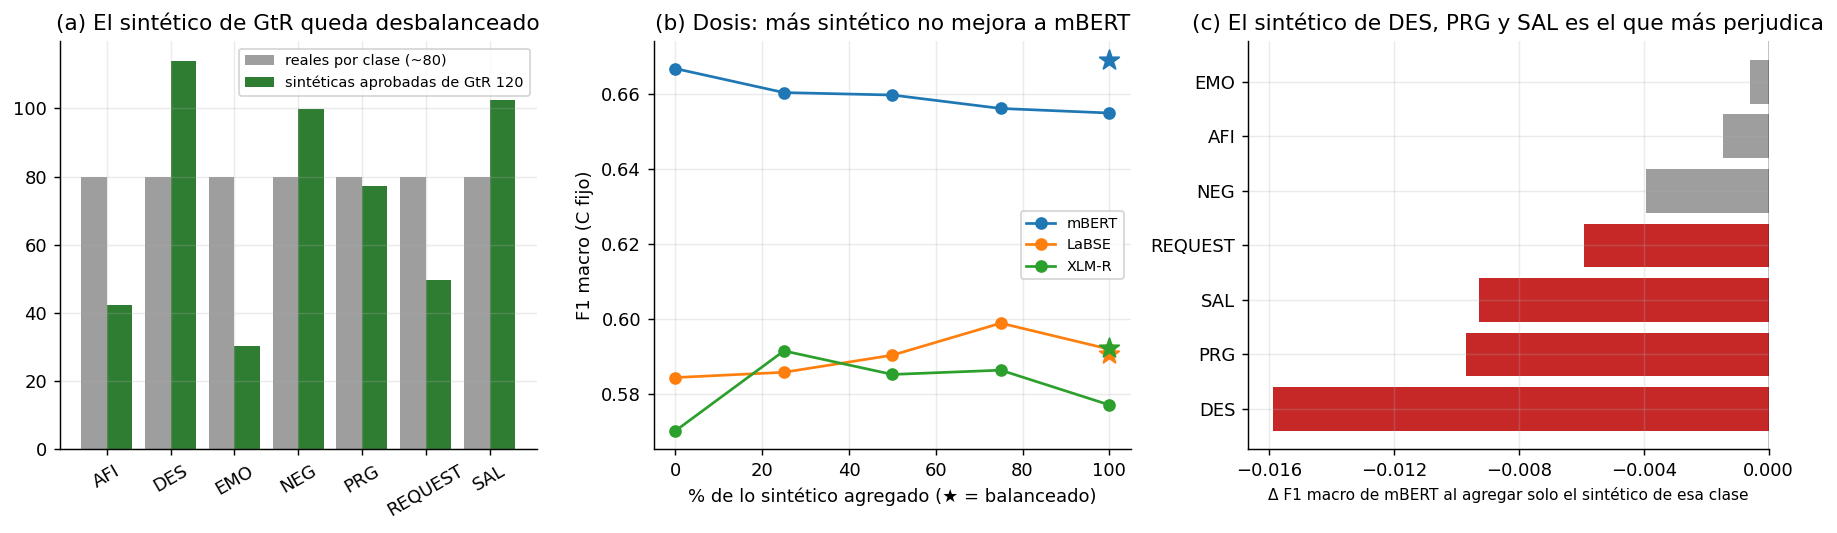

figura: fig7_composicion_y_dosis.png


In [12]:
# ---------------------------------------------------------------- 7. composicion del sintetico y dosis
import glob  # noqa: E402
CACHE = OE2 / "tecnicas_aumento/salidas/en_linea_marcadores_fuentes/generate_then_refine"
import sys  # noqa: E402
sys.path.insert(0, str(RAIZ))
from shiwilu.clasificacion import _normalizar_estricto  # noqa: E402
cuentas = []
for f in range(5):
    g = pd.concat([pd.read_csv(p) for p in sorted(glob.glob(str(CACHE / f"fold{f}_pool*.csv")))])
    ap = g[g.estado_filtro == "aprobado"].copy(); ap["k"] = ap.shiwilu.map(_normalizar_estricto)
    cuentas.append(ap.drop_duplicates(["intencion", "k"]).intencion.value_counts())
comp = pd.concat(cuentas, axis=1).mean(axis=1).reindex(CLASES)
Dd = pd.read_csv(DIAG / "C_dosis.csv"); PCat = pd.read_csv(DIAG / "C_por_categoria.csv")
fig, ejes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.1, 1.1, 1.2]})
ax = ejes[0]
ax.bar(np.arange(7) - 0.2, [80] * 7, 0.4, color="#9e9e9e", label="reales por clase (~80)")
ax.bar(np.arange(7) + 0.2, comp.values, 0.4, color=COL["generate_then_refine"], label="sintéticas aprobadas de GtR 120")
ax.set_xticks(range(7)); ax.set_xticklabels(CLASES, rotation=30); ax.legend(fontsize=8); ax.set_title("(a) El sintético de GtR queda desbalanceado")
ax = ejes[1]
orden = ["0", "25", "50", "75", "100"]
for m in MOD:
    d = Dd[Dd.modelo == m].copy(); d["porcentaje_de_lo_sintetico"] = d["porcentaje_de_lo_sintetico"].astype(str)
    y = [d[d.porcentaje_de_lo_sintetico == o].f1_macro.iloc[0] for o in orden]
    ax.plot([0, 25, 50, 75, 100], y, marker="o", label=NOM[m])
    ax.scatter([100], [d[d.porcentaje_de_lo_sintetico == "balanceado"].f1_macro.iloc[0]], marker="*", s=130, color=ax.lines[-1].get_color(), zorder=5)
ax.set_xlabel("% de lo sintético agregado (★ = balanceado)"); ax.set_ylabel("F1 macro (C fijo)"); ax.legend(fontsize=8); ax.set_title("(b) Dosis: más sintético no mejora a mBERT")
ax = ejes[2]
orden_c = PCat.assign(d=PCat.f1_macro_solo_sintetico_de_esta - PCat.f1_macro_baseline).sort_values("d")
ax.barh(orden_c.categoria, orden_c.d, color=["#c62828" if v < -0.005 else "#9e9e9e" for v in orden_c.d])
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("Δ F1 macro de mBERT al agregar solo el sintético de esa clase", fontsize=8.5); ax.xaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_title("(c) El sintético de DES, PRG y SAL es el que más perjudica")
guardar(fig, "fig7_composicion_y_dosis.png")

## Figura 8. F1 por clase y cambio con cada técnica

**Cómo leerla:** el primer panel es el F1 por clase de los tres modelos sin aumento; los otros tres son el cambio (Δ) al agregar cada técnica (verde = sube, rojo = baja).

**Qué se ve:** DES es la clase más débil (mBERT 0.54, LaBSE 0.41, XLM-R 0.38) y la que más baja con las técnicas (mBERT: Mixup −0.10, Retrotraducción −0.11, GtR −0.06). DES fue la clase **residual** de la anotación por reglas, por eso se mezcla con REQUEST, EMO y AFI.

**Conclusión:** gran parte del límite del F1 está en DES y es un problema de etiqueta. *Firmeza: media.*

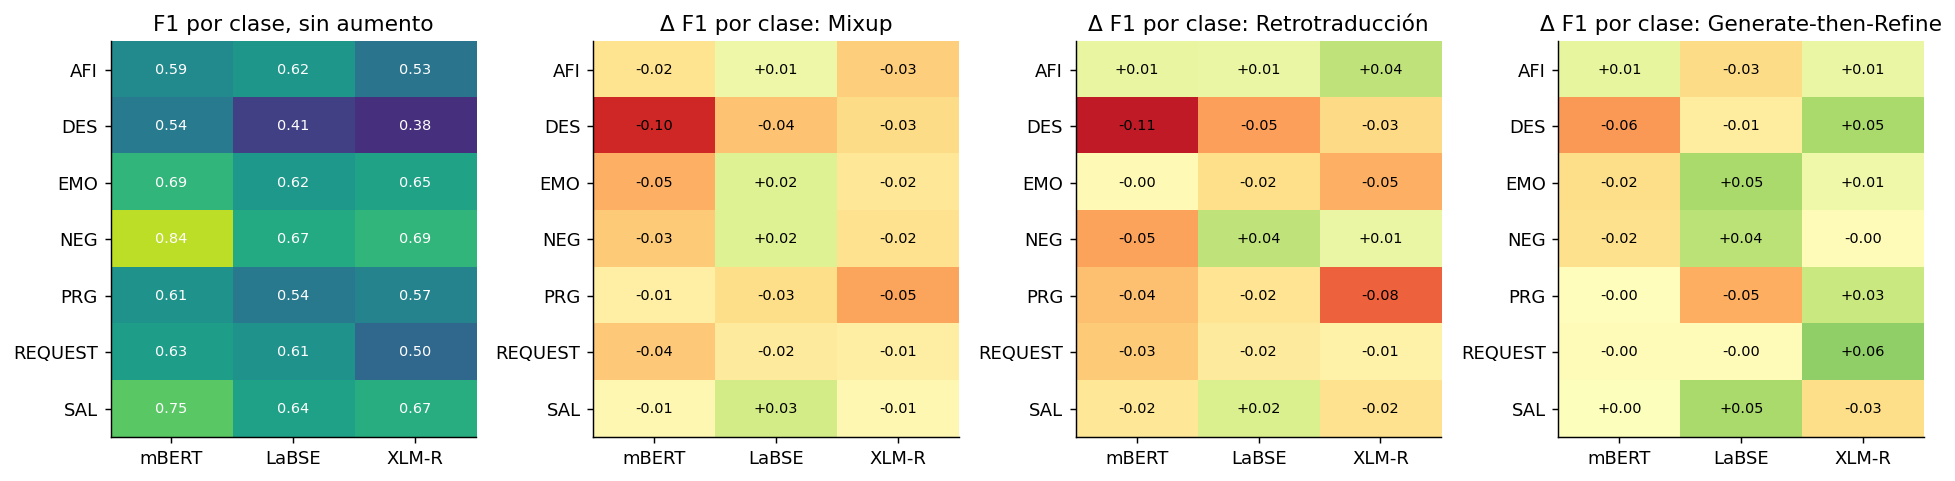

figura: fig8_f1_por_clase.png


In [13]:
# ---------------------------------------------------------------- 8. F1 por clase
def f1c(m, t):
    from sklearn.metrics import f1_score
    g = P[(P.modelo == m) & (P.tecnica == t)]
    return f1_score(g.real, g.prediccion, average=None, labels=CLASES, zero_division=0)
base = pd.DataFrame({NOM[m]: f1c(m, "sin_aumento") for m in MOD}, index=CLASES)
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1, 1, 1, 1]})
im = ejes[0].imshow(base.values, cmap="viridis", vmin=0.3, vmax=0.9, aspect="auto")
ejes[0].set_xticks(range(3)); ejes[0].set_xticklabels(base.columns); ejes[0].set_yticks(range(7)); ejes[0].set_yticklabels(CLASES)
for i in range(7):
    for j in range(3):
        ejes[0].text(j, i, f"{base.values[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)
ejes[0].set_title("F1 por clase, sin aumento"); ejes[0].grid(False)
for ax, t in zip(ejes[1:], TEC[1:]):
    dd = pd.DataFrame({NOM[m]: f1c(m, t) - f1c(m, "sin_aumento") for m in MOD}, index=CLASES)
    ax.imshow(dd.values, cmap="RdYlGn", vmin=-0.12, vmax=0.12, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(3)); ax.set_xticklabels(dd.columns); ax.set_yticks(range(7)); ax.set_yticklabels(CLASES)
    for i in range(7):
        for j in range(3):
            ax.text(j, i, f"{dd.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"Δ F1 por clase: {TNOM[t]}")
guardar(fig, "fig8_f1_por_clase.png")

## Figura 9. ¿Por qué el F1 mejora un poco y luego se estanca con más sintético? ¿Es ruido?

**Fila superior:** curva de F1 al agregar GtR de 20 en 20 por categoría, con cuatro versiones del sintético: todo lo aprobado, **sin ruido de etiqueta**, **sin casi-duplicados** y sin ambos. **Fila inferior:** novedad de cada lote, acuerdo de etiqueta y duplicados por lote, y cuántos ejemplos reales distintos ve Claude.

**Qué se ve:**
- Cualquier efecto aparece con 20–40 por categoría; después la curva queda plana (LaBSE, XLM-R) o baja un poco (mBERT). Todo se mueve dentro de ~0.02.
- El **ruido de etiqueta** (10–29% de cada lote) es constante por lote, se acumula y explica la leve caída de mBERT: sin él, mBERT queda plano en el nivel del baseline.
- La **redundancia** no influye (quitar casi-duplicados no cambia la curva).
- Claude solo ve **36 de ~80** ejemplos reales por clase en 6 lotes, y cada lote es más parecido a los anteriores.

**Conclusión:** la causa principal del estancamiento no parece ser ruido sino un **límite de información** (lo que Claude sabe de cada clase no crece con la cantidad generada). *Firmeza: media-baja (hipótesis respaldada por el diseño, no probada).*

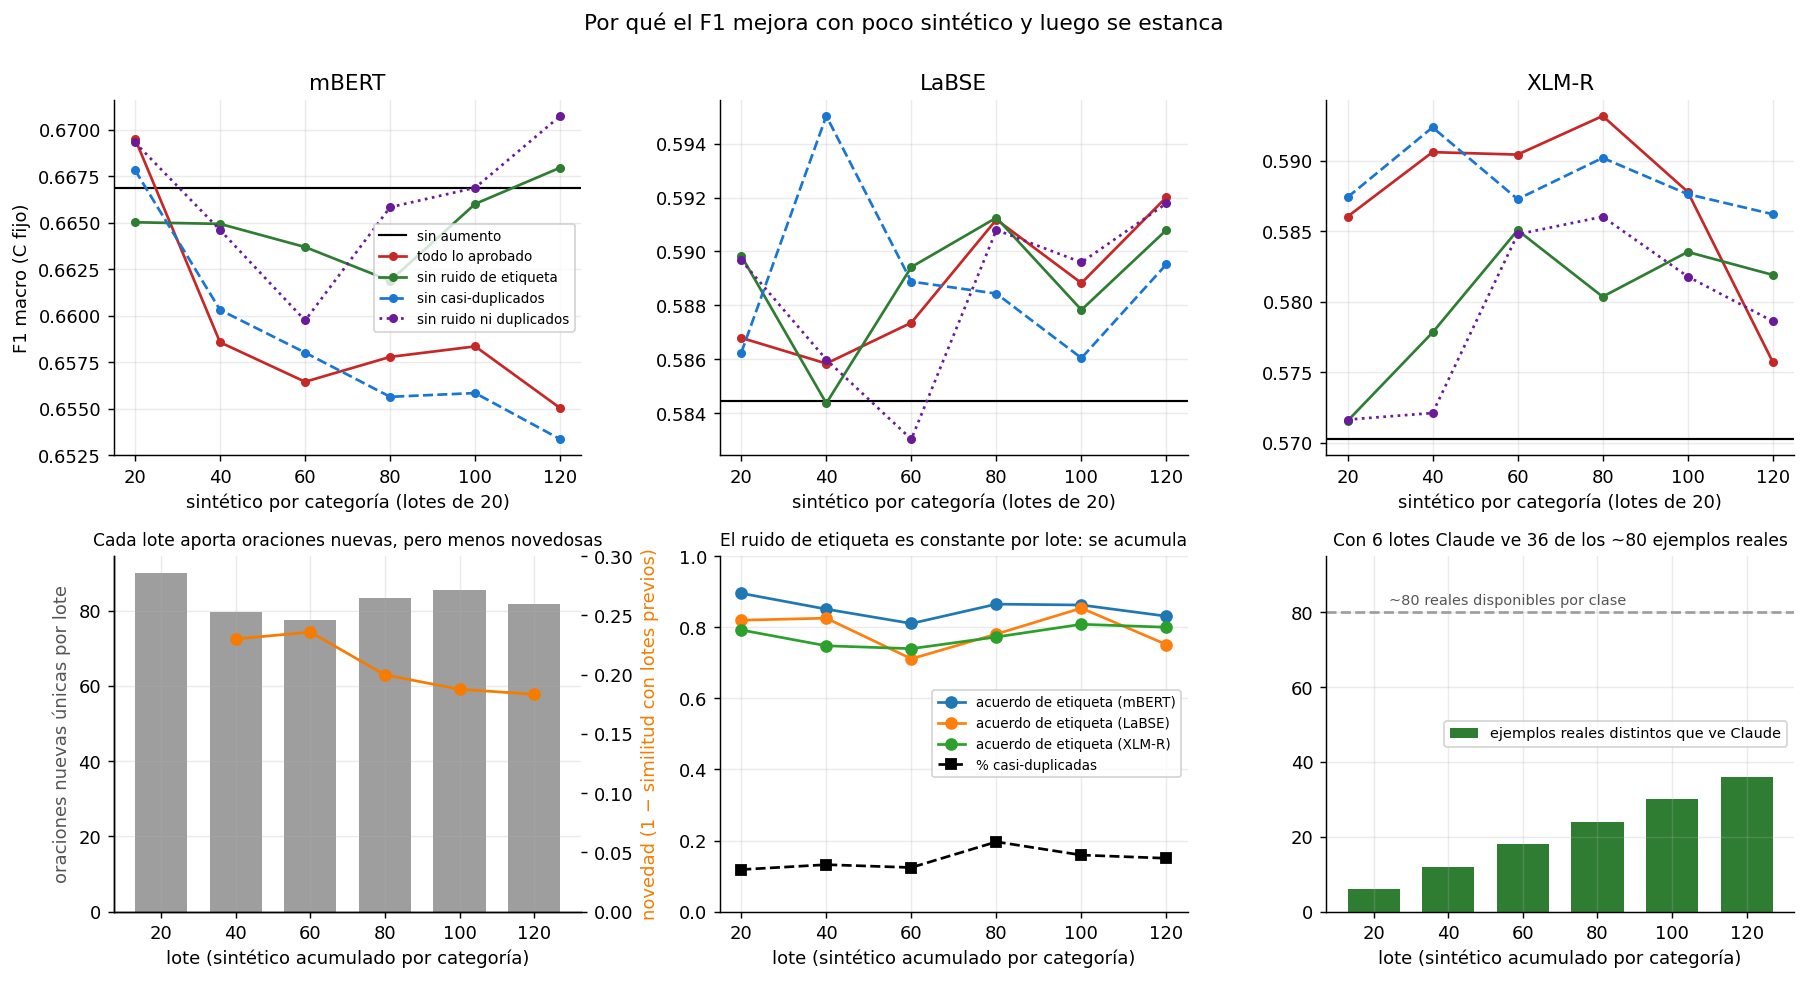

figura: fig9_por_que_se_estanca.png


In [14]:
# ---------------------------------------------------------------- 9. por que el F1 se estanca con mas sintetico
EC = pd.read_csv(DIAG / "E_curva_por_lotes.csv"); EE = pd.read_csv(DIAG / "E_estadisticas_por_lote.csv")
fig, ejes = plt.subplots(2, 3, figsize=(14, 7.5))
VER = {"bruto": ("#c62828", "-", "todo lo aprobado"), "sin_ruido_etiq": ("#2e7d32", "-", "sin ruido de etiqueta"),
       "sin_casi_dup": ("#1976d2", "--", "sin casi-duplicados"), "ambos": ("#6a1b9a", ":", "sin ruido ni duplicados")}
for ax, m in zip(ejes[0], MOD):
    base = EC[(EC.modelo == m) & (EC.version == "sin_aumento")].f1_macro.iloc[0]
    ax.axhline(base, color="k", lw=1.2, label="sin aumento")
    for v, (c, ls, lab) in VER.items():
        g = EC[(EC.modelo == m) & (EC.version == v)].sort_values("lotes")
        ax.plot(g.lotes * 20, g.f1_macro, color=c, ls=ls, marker="o", ms=4, label=lab)
    ax.set_title(NOM[m]); ax.set_xlabel("sintético por categoría (lotes de 20)"); ax.set_xticks([20, 40, 60, 80, 100, 120])
    if m == "mbert":
        ax.set_ylabel("F1 macro (C fijo)"); ax.legend(fontsize=7.5)
ax = ejes[1, 0]
e = EE.groupby("lote").mean(numeric_only=True)
ax.bar(e.index * 20 + 20, e.n_nuevas_unicas, 14, color="#9e9e9e")
ax.set_ylabel("oraciones nuevas únicas por lote", color="#555"); ax.set_xlabel("lote (sintético acumulado por categoría)"); ax.set_xticks([20, 40, 60, 80, 100, 120])
ax2 = ax.twinx(); ax2.plot(e.index * 20 + 20, e.novedad_media, color="#f57c00", marker="o"); ax2.set_ylabel("novedad (1 − similitud con lotes previos)", color="#f57c00"); ax2.set_ylim(0, 0.3); ax2.grid(False)
ax.set_title("Cada lote aporta oraciones nuevas, pero menos novedosas", fontsize=9.5)
ax = ejes[1, 1]
for m in MOD:
    ax.plot(e.index * 20 + 20, e[f"acuerdo_{m}"], marker="o", label=f"acuerdo de etiqueta ({NOM[m]})")
ax.plot(e.index * 20 + 20, e.pct_casi_duplicadas, color="k", ls="--", marker="s", label="% casi-duplicadas")
ax.set_ylim(0, 1); ax.set_xlabel("lote (sintético acumulado por categoría)"); ax.set_xticks([20, 40, 60, 80, 100, 120]); ax.legend(fontsize=7.5)
ax.set_title("El ruido de etiqueta es constante por lote: se acumula", fontsize=9.5)
ax = ejes[1, 2]
ax.bar(e.index * 20 + 20, e.ejemplos_reales_vistos_por_clase, 14, color=COL["generate_then_refine"], label="ejemplos reales distintos que ve Claude")
ax.axhline(80, color="#9e9e9e", ls="--"); ax.text(24, 82, "~80 reales disponibles por clase", fontsize=8, color="#555")
ax.set_ylim(0, 95); ax.set_xlabel("lote (sintético acumulado por categoría)"); ax.set_xticks([20, 40, 60, 80, 100, 120]); ax.legend(fontsize=8, loc="center right")
ax.set_title("Con 6 lotes Claude ve 36 de los ~80 ejemplos reales", fontsize=9.5)
fig.suptitle("Por qué el F1 mejora con poco sintético y luego se estanca", y=1.0)
guardar(fig, "fig9_por_que_se_estanca.png")

## Figura 10. ¿Se arregla seleccionando mejor el sintético? (mBERT, protocolo B)

**Cómo leerla:** izquierda, la diferencia frente a «sin aumento» de las 8 variantes (más dos referencias): balancear por clase, filtrar por similitud con LaBSE, seleccionar por cercanía al centroide y quitar DES. Derecha, el cambio del F1 por clase de cada variante.

**Qué se ve:** ninguna variante supera al baseline (la mejor queda en 0.656 contra 0.665) y tres son significativamente peores. DES baja en todas, **incluso sin su propio sintético** (v3 y v8): su caída viene de que el sintético de las otras clases desplaza su frontera.

**Conclusión:** con todos los datos, **seleccionar mejor el sintético no basta**; no vale la pena gastar créditos en regenerarlo con aprobación balanceada. Donde sí valdría probar es con pocos datos reales (Figura 5). *Firmeza: media (solo mBERT, 2 muestras, diferencias <0.01 no interpretables).*

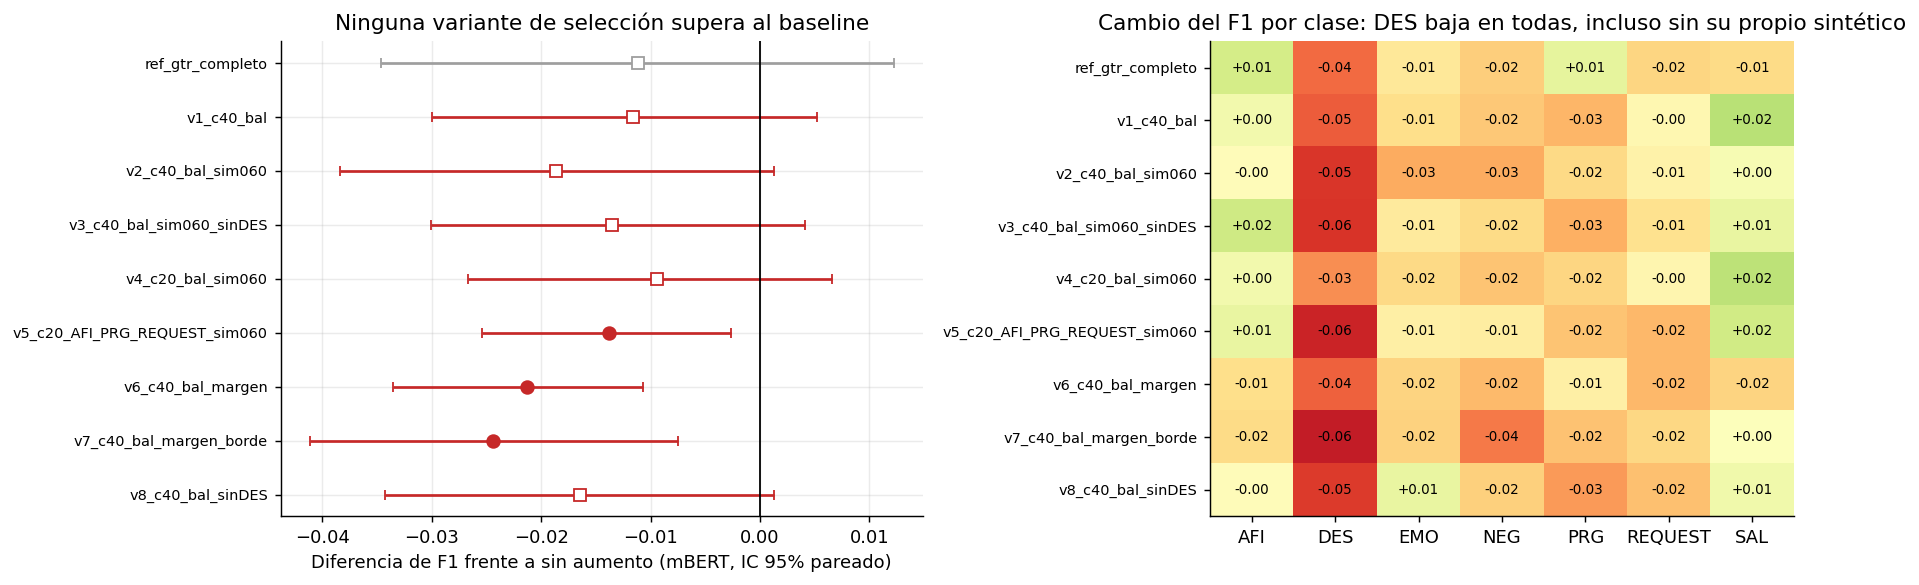

figura: fig10_variantes_seleccion_gtr.png


In [15]:
VR = OE2 / "evaluacion/resultados/variantes_gtr"
if (VR / "resumen_variantes.csv").exists():
    RV = pd.read_csv(VR / "resumen_variantes.csv"); RV = RV[RV.variante != "ref_sin_aumento"].reset_index(drop=True)
    PCv = pd.read_csv(VR / "f1_por_clase.csv").set_index("variante")[CLASES]
    dpc = PCv.sub(PCv.loc["ref_sin_aumento"]).drop(index="ref_sin_aumento")
    fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
    ax = ejes[0]
    for i, r in RV[::-1].reset_index(drop=True).iterrows():
        sig = bool(r.distinguible_de_cero)
        ref = r.variante.startswith("ref_")
        ax.errorbar(r.dif_vs_sin_aumento, i, xerr=[[r.dif_vs_sin_aumento - r.ic95_bajo], [r.ic95_alto - r.dif_vs_sin_aumento]], fmt="o" if sig else "s",
                    color="#9e9e9e" if ref else "#c62828", mfc=("#9e9e9e" if ref else "#c62828") if sig else "white", capsize=3, markersize=7)
    ax.axvline(0, color="k", lw=1); ax.set_yticks(range(len(RV))); ax.set_yticklabels(RV.variante[::-1], fontsize=8)
    ax.set_xlabel("Diferencia de F1 frente a sin aumento (mBERT, IC 95% pareado)"); ax.set_title("Ninguna variante de selección supera al baseline")
    ax = ejes[1]
    ax.imshow(dpc.values, cmap="RdYlGn", vmin=-0.07, vmax=0.07, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(7)); ax.set_xticklabels(CLASES); ax.set_yticks(range(len(dpc))); ax.set_yticklabels(dpc.index, fontsize=8)
    for i in range(len(dpc)):
        for j in range(7):
            ax.text(j, i, f"{dpc.values[i, j]:+.2f}", ha="center", va="center", fontsize=7.5)
    ax.set_title("Cambio del F1 por clase: DES baja en todas, incluso sin su propio sintético")
    guardar(fig, "fig10_variantes_seleccion_gtr.png")

---
**Nota sobre la lectura de todas las figuras:** cada efecto individual es chico (≤0.02) frente al ancho de los intervalos (~0.07), y diferencias menores a ~0.005–0.01 no son interpretables (el valor de C elegido es sensible a diferencias numéricas mínimas entre equipos). La evidencia es **consistente en dirección** más que significativa prueba por prueba.

In [16]:
print('figuras guardadas en:', SAL)
sorted(p.name for p in SAL.glob('*.png'))

figuras guardadas en: C:\Lhia\Cursos Catolica\2026\TESIS\repo tesis\shiwilu-tesis\oe2_aumento_de_datos\analisis_resultados\figuras


['fig10_variantes_seleccion_gtr.png',
 'fig1_f1_12_experimentos.png',
 'fig2_diferencias_pareadas.png',
 'fig3_por_que_gana_mbert.png',
 'fig3b_ngramas_vs_baselines.png',
 'fig4_curva_aprendizaje_real.png',
 'fig5_curva_por_regimen.png',
 'fig6_utilidad_sintetico.png',
 'fig7_composicion_y_dosis.png',
 'fig8_f1_por_clase.png',
 'fig9_por_que_se_estanca.png']